## Conclusiones

Tras muchos experimentos, este enfoque no ha conseguido arrojar resultados satisfactorios, con lo cual deberían descartarse los datasets generados con esta metodología. 

Por otra parte también he probado en este notebook a usar randomforest y xgboost con el dataset entero con aproximadamente el mismo rendimiento.
Esto unido a la exploración con tsne sugiere que el problema no se encuentra en la selección de características. Aún así probaré otros métodos pero creo que deberíamos solicitar o bien más datos o bien más información sobre las variables (sin llegar a datos concretos, creo que estaría bien saber si esos clusters que se forman tienen importancia)

El mejor resultado lo he obtenido con SVC usando min_max e igual resultado con random forest:

### Matriz de Confusión

| | Predicción: 0 (Sana) | Predicción: 1 (Fallo) |
| :--- | :---: | :---: |
| **Real: 0 (Sana)** | 13 | 30 |
| **Real: 1 (Fallo)** | 45 | 118 |

<br>

### Reporte de Clasificación

| Clase / Métrica | Precision | Recall | F1-Score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **0 (Pieza Sana)** | 0.22 | 0.30 | 0.26 | 43 |
| **1 (Pieza con Fallo)**| 0.80 | 0.72 | 0.76 | 163 |
| | | | | |
| **Accuracy** | | | **0.64** | 206 |
| **Macro Avg** | 0.51 | 0.51 | 0.51 | 206 |
| **Weighted Avg** | 0.68 | 0.64 | 0.65 | 206 |


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SEED = 777
np.random.seed(SEED)

In [3]:
from sklearn.model_selection import train_test_split

# cargo el dataset básico primero para separarlo en train y test
basic = pd.read_csv('../data/scaled/data_basic.csv')


# separación de características y objetivo
X_basic = basic.drop('Variable de Salida', axis=1)
y_basic = basic['Variable de Salida']

# separación en train y test
X_basic_train, X_basic_test, y_basic_train, y_basic_test = train_test_split(X_basic, y_basic, test_size=0.2, random_state = SEED, shuffle=True, stratify=y_basic)

# uno de nuevo y los meto ya en el 

basic = (pd.concat([X_basic_train, y_basic_train], axis=1), pd.concat([X_basic_test, y_basic_test], axis=1))


In [4]:
# cargar el resto de los datos en un diccionario de datasets, donde la clave es el tipo de trato y el valor una tupla (train, test)

datasets = {
    'basic': basic,
    'max_abs': (pd.read_csv('../data/scaled/data_trainmax_abs.csv'), pd.read_csv('../data/scaled/data_testmax_abs.csv')),
    'min_max': (pd.read_csv('../data/scaled/data_trainmin_max.csv'), pd.read_csv('../data/scaled/data_testmin_max.csv')),
    'robust': (pd.read_csv('../data/scaled/data_trainrobust.csv'), pd.read_csv('../data/scaled/data_testrobust.csv')),
    'standard': (pd.read_csv('../data/scaled/data_trainstandard.csv'), pd.read_csv('../data/scaled/data_teststandard.csv'))
}

In [5]:
# antes de nada divido ya en X e y los datasets del diccionario

for name, (train, test) in datasets.items():
    X_train = train.drop('Variable de Salida', axis=1)
    y_train = train['Variable de Salida']

    X_test = test.drop('Variable de Salida', axis=1)
    y_test = test['Variable de Salida']

    datasets[name] = (X_train, X_test, y_train, y_test)

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# el primero método de selección de características a utilizar será el mítico
# random forest, por la simplicidad, no estoy entrenando el mejor model aún
# solo sacando características, esto lo voy a hacer sobre el dataset basic
# dado que para árboles no hay necesidad de escalar los datos

X_train, X_test, y_train, y_test = datasets['basic']

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

random_forest = RandomForestClassifier(max_depth=5,
                                       min_samples_leaf=20,
                                       class_weight='balanced',
                                       random_state=SEED,
                                       n_jobs=-1,
                                       )

rfecv = RFECV(estimator=random_forest,
              cv=cv,
              scoring='f1_macro',
              n_jobs=-1)

rfecv.fit(X_train, y_train)

print(f'Numero optimo de características: {rfecv.n_features_}')
rfecv.support_





Numero optimo de características: 102


array([ True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

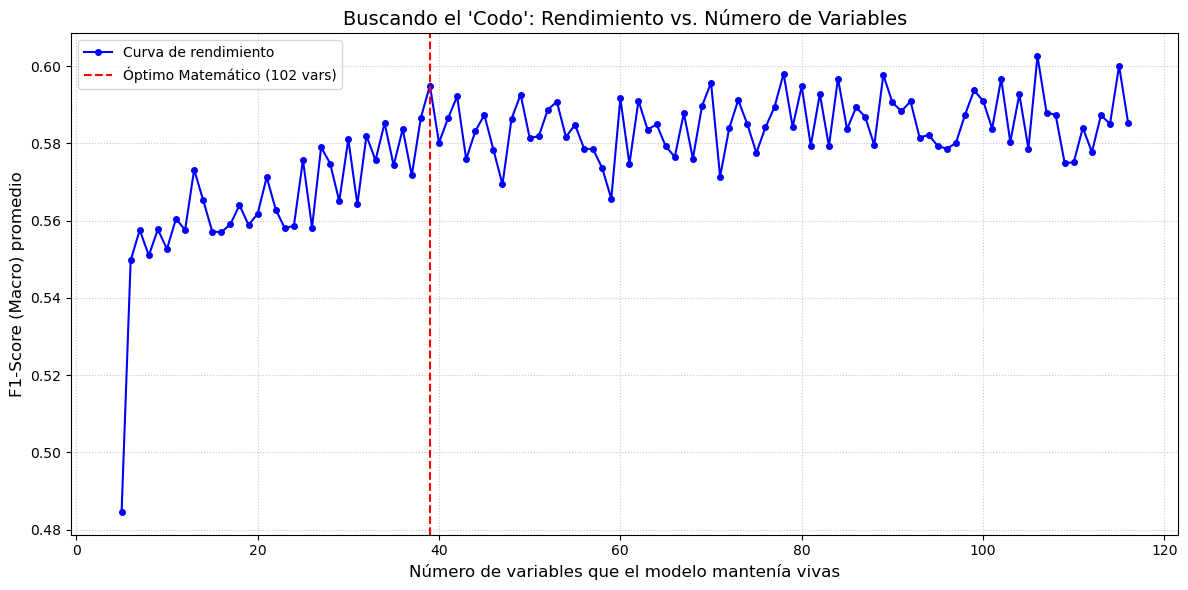

In [8]:
# tras probar un par de combinaciones, veo que esto no está funcionando muy bien,
# forzando un poco solo consigo que se quede con 89 variables como mínimo,
# esto se debe a la sensibilidad al f1-score, el gráfico se lo debemos a gemini,

resultados_cv = rfecv.cv_results_['mean_test_score']

plt.figure(figsize=(12, 6))
plt.title("Buscando el 'Codo': Rendimiento vs. Número de Variables", fontsize=14)
plt.xlabel("Número de variables que el modelo mantenía vivas", fontsize=12)
plt.ylabel("F1-Score (Macro) promedio", fontsize=12)

# Asumiendo que pusiste min_features_to_select=5 en tu RFECV
eje_x = range(5, len(resultados_cv) + 5) 

# Dibujamos la línea principal
plt.plot(eje_x, resultados_cv, marker='o', color='b', markersize=4, label='Curva de rendimiento')

# Marcamos el "óptimo" engañoso que te dio el modelo
plt.axvline(x=39, color='r', linestyle='--', 
            label=f'Óptimo Matemático ({rfecv.n_features_} vars)')

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
from sklearn.feature_selection import RFE
# con este gráfico podemos ver que a partir de las 9 variables el aumento en el
# f1 no es significativo

n_features = 39

X_train, X_test, y_train, y_test = datasets['basic']

random_forest = RandomForestClassifier(max_depth=5,
                                       min_samples_leaf=20,
                                       class_weight='balanced',
                                       random_state=SEED,
                                       n_jobs=-1)

rfe = RFE(estimator=random_forest,
              n_features_to_select=n_features)


rfe.fit(X_train, y_train)


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestC...dom_state=777)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",39
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


In [10]:
columnas_28 = X_train.columns[rfe.support_] #son 39 en realidad pero cambiar todos los nombres me da mucha pereza

In [ ]:
# ahora dos nuevos diccionarios con los datasets modificados

datasets_28 = {}

for name, (X_train, X_test, y_train, y_test) in datasets.items():
    datasets_28[name] = (X_train[columnas_28], X_test[columnas_28], y_train, y_test)
    #pd.concat([X_train, y_train], axis=1).to_csv(f'../data/selected_by_random_forest/data_train{name}_39.csv')
    #pd.concat([X_test, y_test], axis=1).to_csv(f'../data/selected_by_random_forest/data_test{name}_39.csv')


In [110]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# ahora repetimos como en el notebook anterior, modelos clásicos, empezando
# por regresión logística

# creo un diccionario con los modelos logísticos
modelos_rl_28 = {}

for nombre, (X_train, X_test, y_train, y_test,) in datasets_28.items():
    print(nombre)
    rl = LogisticRegression(max_iter=10000, random_state=SEED, class_weight='balanced', penalty='l1', solver='saga')

    rl.fit(X_train, y_train)

    modelos_rl_28[nombre] = rl

    predicciones = rl.predict(X_test)

    print(confusion_matrix(y_test, predicciones))
    print(classification_report(y_test, predicciones))





basic


/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[[ 18  25]
 [ 61 102]]
              precision    recall  f1-score   support

           0       0.23      0.42      0.30        43
           1       0.80      0.63      0.70       163

    accuracy                           0.58       206
   macro avg       0.52      0.52      0.50       206
weighted avg       0.68      0.58      0.62       206

max_abs


/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[[ 18  25]
 [ 62 101]]
              precision    recall  f1-score   support

           0       0.23      0.42      0.29        43
           1       0.80      0.62      0.70       163

    accuracy                           0.58       206
   macro avg       0.51      0.52      0.50       206
weighted avg       0.68      0.58      0.61       206

min_max
[[21 22]
 [64 99]]
              precision    recall  f1-score   support

           0       0.25      0.49      0.33        43
           1       0.82      0.61      0.70       163

    accuracy                           0.58       206
   macro avg       0.53      0.55      0.51       206
weighted avg       0.70      0.58      0.62       206

robust


/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of pe

[[18 25]
 [66 97]]
              precision    recall  f1-score   support

           0       0.21      0.42      0.28        43
           1       0.80      0.60      0.68       163

    accuracy                           0.56       206
   macro avg       0.50      0.51      0.48       206
weighted avg       0.67      0.56      0.60       206

standard


/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[[18 25]
 [66 97]]
              precision    recall  f1-score   support

           0       0.21      0.42      0.28        43
           1       0.80      0.60      0.68       163

    accuracy                           0.56       206
   macro avg       0.50      0.51      0.48       206
weighted avg       0.67      0.56      0.60       206



In [ ]:
# La mejora respecto del dataset tratado con PCA es prácticamente nula. Lo cual
# era de esperar puesto que ya ha quedado bastante claro que la naturaleza de 
# el dataset no es lineal.

In [88]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# ahora probaré con una svm

# parámetros a probar
param_grid = [
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale','auto', 0.1, 0.01, 0.001]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
        'degree': [2, 3]
    }
]

modelos_svc_28 = {}

for nombre, (X_train, X_test, y_train, y_test) in datasets_28.items():
    svc = SVC(class_weight='balanced', max_iter=50000)
    
    clf = GridSearchCV(svc, param_grid, n_jobs=-1, cv=5, verbose=0, refit=True, scoring='f1_macro')
    clf.fit(X_train, y_train)

    # al poner refit = True, clf actúa directamente como mejor modelo
    modelos_svc_28[nombre] = clf

    predicciones = clf.predict(X_test)

    print(nombre)
    print(confusion_matrix(y_test, predicciones))
    print(classification_report(y_test, predicciones))





/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/py

basic
[[ 17  26]
 [ 57 106]]
              precision    recall  f1-score   support

           0       0.23      0.40      0.29        43
           1       0.80      0.65      0.72       163

    accuracy                           0.60       206
   macro avg       0.52      0.52      0.50       206
weighted avg       0.68      0.60      0.63       206



/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/py

max_abs
[[ 18  25]
 [ 61 102]]
              precision    recall  f1-score   support

           0       0.23      0.42      0.30        43
           1       0.80      0.63      0.70       163

    accuracy                           0.58       206
   macro avg       0.52      0.52      0.50       206
weighted avg       0.68      0.58      0.62       206



/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/py

min_max
[[ 14  29]
 [ 47 116]]
              precision    recall  f1-score   support

           0       0.23      0.33      0.27        43
           1       0.80      0.71      0.75       163

    accuracy                           0.63       206
   macro avg       0.51      0.52      0.51       206
weighted avg       0.68      0.63      0.65       206



/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/py

robust
[[ 10  33]
 [ 40 123]]
              precision    recall  f1-score   support

           0       0.20      0.23      0.22        43
           1       0.79      0.75      0.77       163

    accuracy                           0.65       206
   macro avg       0.49      0.49      0.49       206
weighted avg       0.67      0.65      0.66       206



/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/python3.14/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/lucas/miniconda3/envs/pluto/lib/py

standard
[[ 12  31]
 [ 43 120]]
              precision    recall  f1-score   support

           0       0.22      0.28      0.24        43
           1       0.79      0.74      0.76       163

    accuracy                           0.64       206
   macro avg       0.51      0.51      0.50       206
weighted avg       0.67      0.64      0.66       206



In [107]:
# voy a enfocarme en min_max que ha dado mejores resultados

X_train, X_test, y_train, y_test = datasets_28['min_max']

svc_base = SVC(class_weight='balanced', random_state=SEED)

param_grid_svc = [
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 50, 100], 
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1] 
    },
    {
        'kernel': ['poly'],
        'degree': [2, 3],           
        'C': [0.1, 1, 10, 50],
        'gamma': ['scale', 'auto']
    }
]

grid_svc = GridSearchCV(
    estimator=svc_base,
    param_grid=param_grid_svc,
    scoring='f1_macro', 
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_svc.fit(X_train, y_train)

print(confusion_matrix(y_test, predicciones))
print(classification_report(y_test, predicciones))

Fitting 5 folds for each of 46 candidates, totalling 230 fits
[[ 13  30]
 [ 45 118]]
              precision    recall  f1-score   support

           0       0.22      0.30      0.26        43
           1       0.80      0.72      0.76       163

    accuracy                           0.64       206
   macro avg       0.51      0.51      0.51       206
weighted avg       0.68      0.64      0.65       206



In [108]:
print(f"Mejores parámetros para SVC:\n{grid_svc.best_params_}")

Mejores parámetros para SVC:
{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
# de nuevo, la mejora no ha sido demasiado grande, vamos ahora a probar con RandomForest

# en este caso nos sirve con probarlo para el dataset basic de 25 variables y 9

X_train_28, X_test_28, y_train_28, y_test_28 = datasets_28['basic']
X_train, X_test, y_train, y_test = datasets['basic']

rf_modelo_28 = RandomForestClassifier(
    n_estimators=400,          # 200 árboles
    max_depth=10,              # Profundidad controlada para no sobreajustar
    min_samples_leaf=20,        # Exigimos evidencia para cada regla
    class_weight='balanced',   # Vital para contrarrestar el 80% NOK
    random_state=SEED,
    n_jobs=-1
)



rf_modelo = RandomForestClassifier(
    n_estimators=200,          # 200 árboles
    max_depth=10,              # Profundidad controlada para no sobreajustar
    min_samples_leaf=15,        # Exigimos evidencia para cada regla
    class_weight='balanced',   # Vital para contrarrestar el 80% NOK
    random_state=SEED,
    n_jobs=-1
)

rf_modelo_28.fit(X_train_28, y_train_28)

rf_modelo.fit(X_train, y_train)


predicciones_28 = rf_modelo_28.predict(X_test_28)

predicciones = rf_modelo.predict(X_test)



print(confusion_matrix(y_test_28, predicciones_28))
print(classification_report(y_test_28, predicciones_28))



print(confusion_matrix(y_test, predicciones))
print(classification_report(y_test, predicciones))


[[ 14  29]
 [ 50 113]]
              precision    recall  f1-score   support

           0       0.22      0.33      0.26        43
           1       0.80      0.69      0.74       163

    accuracy                           0.62       206
   macro avg       0.51      0.51      0.50       206
weighted avg       0.68      0.62      0.64       206

[[ 13  30]
 [ 45 118]]
              precision    recall  f1-score   support

           0       0.22      0.30      0.26        43
           1       0.80      0.72      0.76       163

    accuracy                           0.64       206
   macro avg       0.51      0.51      0.51       206
weighted avg       0.68      0.64      0.65       206



In [ ]:
# los resultados en este escenario tampoco han sido muy reconfortantes

In [90]:
import xgboost as xgb

# ahora probaré con xgboost

peso_positivo = 0.25

xgb_28 = xgb.XGBClassifier(
    scale_pos_weight=peso_positivo,
    n_estimators=800,
    max_depth=4,
    learning_rate=0.01,
    random_state=SEED,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_ = xgb.XGBClassifier(
    scale_pos_weight=peso_positivo,
    n_estimators=800,
    max_depth=4,
    learning_rate=0.01,
    random_state=SEED,
    n_jobs=-1,
    eval_metric='logloss'
)


xgb_28.fit(X_train_28, y_train_28)
xgb_.fit(X_train, y_train)

predicciones_28 = xgb_28.predict(X_test_28)
predicciones = xgb_.predict(X_test)


print(confusion_matrix(y_test_28, predicciones_28))
print(classification_report(y_test_28, predicciones_28))

print(confusion_matrix(y_test, predicciones))
print(classification_report(y_test, predicciones))


[[  8  35]
 [ 60 103]]
              precision    recall  f1-score   support

           0       0.12      0.19      0.14        43
           1       0.75      0.63      0.68       163

    accuracy                           0.54       206
   macro avg       0.43      0.41      0.41       206
weighted avg       0.62      0.54      0.57       206

[[ 11  32]
 [ 49 114]]
              precision    recall  f1-score   support

           0       0.18      0.26      0.21        43
           1       0.78      0.70      0.74       163

    accuracy                           0.61       206
   macro avg       0.48      0.48      0.48       206
weighted avg       0.66      0.61      0.63       206



In [91]:
from sklearn.model_selection import GridSearchCV

xgb_base = xgb.XGBClassifier(
    random_state=SEED,
    eval_metric='logloss',
    tree_method='hist',
    scale_pos_weight=0.25
)

param_grid = {
    'learning_rate': [0.01],
    'max_depth': [5],
    'n_estimators': [900],
    'min_child_weight': [10, 11],
    'subsample': [0.95, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'gamma': [0.3]
}

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_28, y_train_28)

print(f"Mejores hiperparámetros encontrados:\n{grid_xgb.best_params_}")

modelo_ganador = grid_xgb.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores hiperparámetros encontrados:
{'colsample_bytree': 0.7, 'gamma': 0.3, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 10, 'n_estimators': 900, 'subsample': 0.95}


In [99]:
threshold = 0.5  # ajusta según necesites
probs_ganador = modelo_ganador.predict_proba(X_test_28)[:, 1]
predicciones_ganador = (probs_ganador > threshold).astype(int)

print(confusion_matrix(y_test, predicciones_ganador))
print(classification_report(y_test, predicciones_ganador))

[[ 15  28]
 [ 58 105]]
              precision    recall  f1-score   support

           0       0.21      0.35      0.26        43
           1       0.79      0.64      0.71       163

    accuracy                           0.58       206
   macro avg       0.50      0.50      0.48       206
weighted avg       0.67      0.58      0.62       206

